# Inspect available evolutionary models

Let's explore relevant information about the evolutionary models available via SEDA.

In [1]:
import seda
import os
import numpy as np
import matplotlib.pyplot as plt
from astropy.constants import R_jup, R_sun
from matplotlib.ticker import AutoMinorLocator, StrMethodFormatter


    SEDA v0.1.dev1342 package imported


## Available models

In [2]:
seda.models.EvolutionaryModels().available_models

['Sonora_Diamondback', 'Sonora_Bobcat']

## Evolutionary model grids overview

Read relevant information from models of interest.

Let's select the 'Sonora_Diamondback' grid:

In [3]:
model = 'Sonora_Diamondback'

Read some parameters:

In [4]:
print(seda.models.EvolutionaryModels(model).ref) # reference
print(seda.models.EvolutionaryModels(model).ADS) # link to paper
print(seda.models.EvolutionaryModels(model).download) # link to download the models
print(seda.models.EvolutionaryModels(model).columns) # columns in each evolutionary table
print(seda.models.EvolutionaryModels(model).units) # units of each column

Morley et al (2024)
https://ui.adsabs.harvard.edu/abs/2024ApJ...975...59M/abstract
https://zenodo.org/records/12735103
['mass', 'age', 'logL', 'Teff', 'logg', 'radius']
{'mass': 'M_sun', 'age': 'Gyr', 'logL': 'log10(L/Lsun)', 'Teff': 'K', 'logg': 'cgs dex', 'radius': 'R_sun'}


Look at other available parameters:

In [5]:
help(seda.models.EvolutionaryModels)

Help on class EvolutionaryModels in module seda.models:

class EvolutionaryModels(builtins.object)
 |  EvolutionaryModels(model=None)
 |  
 |  Description:
 |  ------------
 |          See available evolutionary models and get basic parameters from a desired grid.
 |  
 |  Parameters:
 |  -----------
 |  - model : str, optional
 |          Evolutionary models. If provided, the model metadata from its ``config.json``
 |          (e.g. ``ref``, ``bibcode``, ``ADS``, ``download``, ``columns``, ``units``) is
 |          assigned as attributes. If omitted, only ``available_models`` is set.
 |  
 |  Attributes:
 |  -----------
 |  - available_models (list) : Evolutionary models available on SEDA.
 |  
 |  Example:
 |  --------
 |  >>> import seda
 |  >>>
 |  >>> # see available evolutionary models
 |  >>> seda.models.EvolutionaryModels().available_models
 |      ['Sonora_Bobcat']
 |  >>>
 |  >>> # see the reference for a given evolutionary model
 |  >>> seda.models.EvolutionaryModels('Sonora

Read more about the [available evolutionary models](https://seda.readthedocs.io/en/latest/overview.html#evolutionary-models).

Check the bundled evolutionary tables along with the coverage of their columns:

In [6]:
filename = 'hybrid-grav_f2_m-0.5_mass' # bundled table for Sonora Diamondback

print('Bundled tables:')
print(seda.models.EvolutionaryModels(model).available_tables)

grid = seda.models.read_evolutionary_model(filename=filename, model=model)

Lbol = 10.0 ** grid['logL']
R_rjup = (grid['radius'] * R_sun).to(R_jup).value

coverage = {
    'Lbol': [Lbol.min(), Lbol.max()],
    'R': [R_rjup.min(), R_rjup.max()],
}
for col in grid:
    if col in ('logL', 'radius'):
        continue
    coverage[col] = [grid[col].min(), grid[col].max()]

coverage

Bundled tables:
['hybrid-grav_f2_m+0.5_mass', 'hybrid-grav_f2_m-0.5_mass', 'hybrid-grav_f2_m0.0_mass', 'hybrid_f2_m+0.5_mass', 'hybrid_f2_m-0.5_mass', 'hybrid_f2_m0.0_mass', 'nc_m+0.5_mass', 'nc_m-0.5_mass', 'nc_m0.0_mass']


{'Lbol': [1.6436146363905513e-08, 0.0016634126503701698],
 'R': [7.259444413360935, 20.74683041459184],
 'mass': [0.0005, 0.08],
 'age': [0.002, 13.0],
 'Teff': [201.52, 2499.38],
 'logg': [2.741, 5.489]}

## Coverage of evolutionary grid parameters

Plot bolometric luminosity against radius, the two observables used by `seda.phy_params.evol_params`. A third grid column can be shown as a color scale to explore how different parameters vary across the grid.

In [11]:
def plot_evolutionary_coverage(model, filename, cparam='age', xlog=True, ylog=False, save=False):
    """Plot Lbol vs. R with a third evolutionary parameter as the color axis."""

    grid = seda.models.read_evolutionary_model(filename=filename, model=model)
    model_info = seda.models.EvolutionaryModels(model)
    units = model_info.units

    Lbol = 10.0 ** grid['logL']
    R_rjup = (grid['radius'] * R_sun).to(R_jup).value

    interp_axes = {'logL', 'radius'}
    valid_cparams = [col for col in grid if col not in interp_axes]
    if cparam not in grid:
        raise ValueError(
            f'{cparam!r} is not a column in this table. '
            f'Choose one of: {valid_cparams}'
        )

    fig, ax = plt.subplots()
    sc = ax.scatter(Lbol, R_rjup, c=grid[cparam], s=5, zorder=3)
    cbar = plt.colorbar(sc, ax=ax)
    cunit = units.get(cparam, '')
    cbar.set_label(f'{cparam} ({cunit})' if cunit else cparam)

    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    if xlog:
        ax.set_xscale('log')
        ax.xaxis.set_major_formatter(StrMethodFormatter('{x:.1e}'))
    if ylog:
        ax.set_yscale('log')
        ax.yaxis.set_major_formatter(StrMethodFormatter('{x:.2f}'))
    ax.grid(True, which='both', color='gainsboro', alpha=0.5)

    ax.set_xlabel('Lbol (L_sun)')
    ax.set_ylabel('R (R_jup)')
    ax.set_title(f'{model_info.name}: {filename}')

    if save:
        out_file = f'{model}_{filename}_{cparam}_coverage.pdf'
        plt.savefig(out_file, bbox_inches='tight')

    return fig, ax

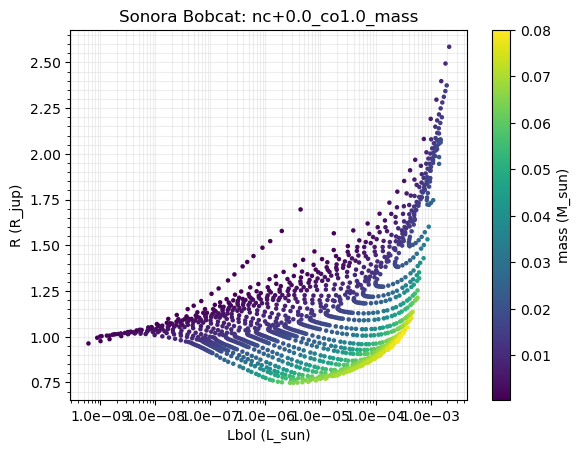

In [15]:
cparam = 'mass' # auxiliary axis: model parameters
fig, ax = plot_evolutionary_coverage(model=model, filename=filename, cparam=cparam, xlog=True, save=True)

We can use any inferred grid column as the auxiliary axis:

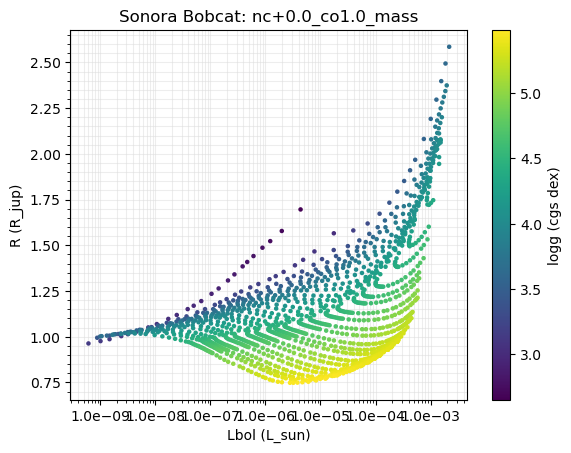

In [17]:
cparam = 'logg'
fig, ax = plot_evolutionary_coverage(model=model, filename=filename, cparam=cparam, xlog=True, save=True)

Let's check the coverage of the Sonora Bobcat evolutionary tables

['nc+0.0_co1.0_mass', 'nc+0.5_co1.0_mass', 'nc-0.5_co1.0_mass']


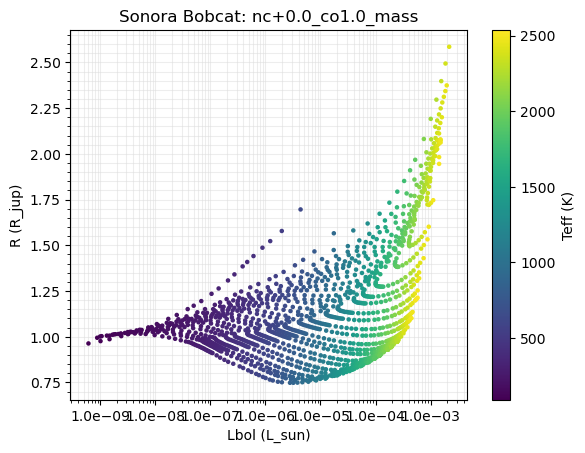

In [18]:
model = 'Sonora_Bobcat'
filename = 'nc+0.0_co1.0_mass' # cloud-free evolution at solar metallicity

print(seda.models.EvolutionaryModels(model).available_tables)

cparam = 'Teff'
fig, ax = plot_evolutionary_coverage(model=model, filename=filename, cparam=cparam, xlog=True, save=True)